In [1]:
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df0 = pd.read_csv("divar.csv",low_memory=False)
df1 = pd.read_csv("iran_city_classification.csv",low_memory=False)

In [3]:
df1.rename(columns={"نام شهر":"city_slug"},inplace=True)

In [4]:
merge_df = pd.merge(df1,df0,on="city_slug").copy()

In [5]:
merge_df = merge_df[merge_df["cat3_slug"].isin(['villa', 'apartment-rent', 'apartment-sell', 'presell','shop-rent',
'house-villa-sell', 'plot-old', 'house-villa-rent','industry-agriculture-business-rent',])]

In [6]:
big_city = merge_df[merge_df["دسته‌بندی"]=="کلان‌شهر"]["building_size"].dropna()

In [7]:
small_city = merge_df[merge_df["دسته‌بندی"]=="شهر کوچک"]["building_size"].dropna()

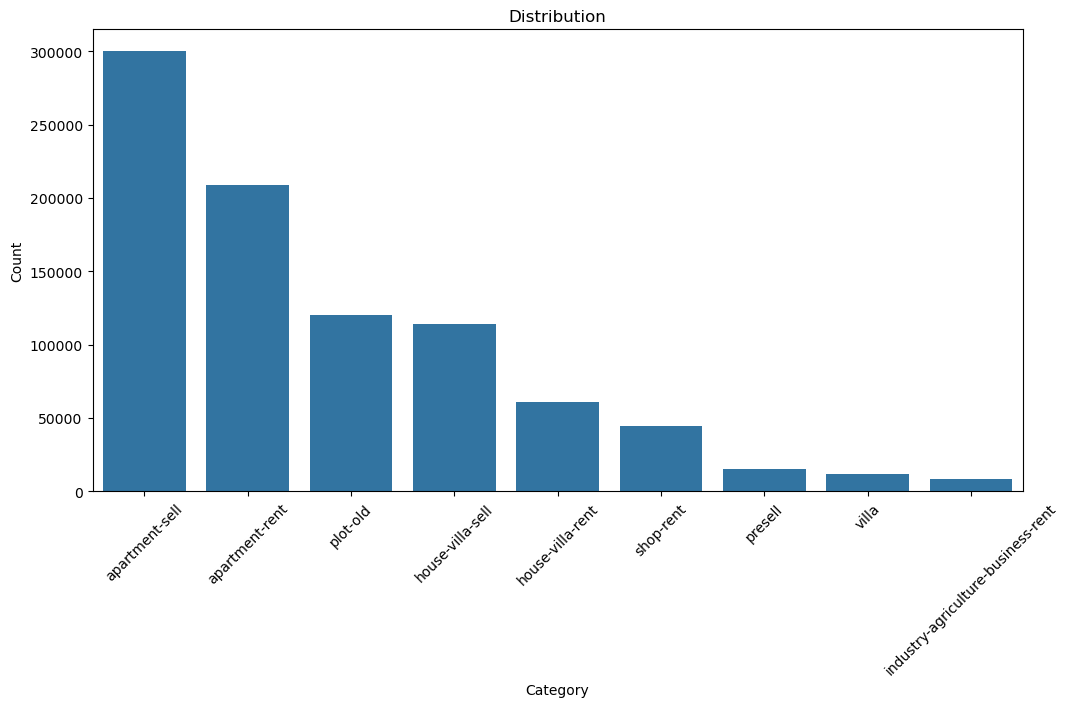

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(data=merge_df,x="cat3_slug",order=merge_df["cat3_slug"].value_counts().index)
plt.xticks(rotation=45)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Distribution")
plt.show()

In [9]:
utest,p = mannwhitneyu(big_city,small_city,alternative="less")

In [10]:
if p < 0.05:
    print("Reject H0")
else:
    print("Cant Reject H0")

Reject H0


# Because the data distribution was not normal, the Mann–Whitney U test was used. Based on the results, the null hypothesis (H0) is rejected and the the question is based on the alternative hypothesis.
## h0 = merge_df[merge_df["دسته‌بندی"]=="شهر کوچک"]["building_size"].mean() <= merge_df[merge_df["دسته‌بندی"]=="کلان‌شهر"]["building_size"].mean()
## h1 = (merge_df[merge_df["دسته‌بندی"]=="کلان‌شهر"]["building_size"].mean()) < merge_df[merge_df["دسته‌بندی"]=="شهر کوچک"]["building_size"].mean()